# Étape 1

On considère le fichier lending_club_loans.csv  
Après étude de ce dataset, indiquer les points marquants de votre exploration. Pour chaque observation, indiquer l’opération à effectuer qui serait la plus appropriée. De ce fait, dans cette phase d’exploration, on considère les points suivants :  
* Quelles sont les descripteurs (colonnes) du dataset?  
* Combien d'enregistrements (lignes) ont été fournis? 
* Quel est le format des données. Par exemple, dans quel format les dates sontfournies, existe-t-il des valeurs numériques, à quoi ressemblent les différentesvaleurs catégoriques ?  
* Y a-t-il des valeurs manquantes ?  
* Est-ce qu’il y’a des dépendances évidentes au niveau des descripteurs?  

D’autres observations sur le dataset qui pourraient être pertinentes ?

In [2]:

import pandas as pd 
import numpy as np 
from utils.utils import distributional_summary, degree_completeness, plot_distributions, plot_boxplots
import matplotlib.pyplot as plt 
from typing import Dict, List, Callable, Any, Tuple 


df_data = pd.read_csv('data/lending_club_loans.csv') 
labels = pd.read_excel('data/lending_club_data_dic.xlsx') 
labels.index = labels['LoanStatNew'] 
labels = labels.drop(columns=['LoanStatNew']) 
labels = labels.loc[df_data.columns] # ! limits labels to our variables of interests 


## Apercu des datas

In [3]:
print(f"Nombre d'observations/lignes: {df_data.shape[0]}") 
print(f'Nombre de colonnes: {df_data.shape[1]}') 

df_data

Nombre d'observations/lignes: 39786
Nombre de colonnes: 47


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,application_type,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,0.00,Jan-15,171.62,Jan-17,0.0,INDIVIDUAL,0.0,0,0.0,0.0
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,1.11,Apr-13,119.66,Oct-16,0.0,INDIVIDUAL,0.0,0,0.0,0.0
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,0.00,Jun-14,649.91,Jan-17,0.0,INDIVIDUAL,0.0,0,0.0,0.0
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,0.00,Jan-15,357.48,Apr-16,0.0,INDIVIDUAL,0.0,0,0.0,0.0
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,0.00,Jan-17,67.30,Jan-17,0.0,INDIVIDUAL,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39781,92187,92174,2500,2500,1075.0,36 months,8.07%,78.42,A,A4,...,0.00,Jul-10,80.90,Jun-10,NaN,INDIVIDUAL,NaN,0,NaN,NaN
39782,90665,90607,8500,8500,875.0,36 months,10.28%,275.38,C,C1,...,0.00,Jul-10,281.94,Jul-10,NaN,INDIVIDUAL,NaN,0,NaN,NaN
39783,90395,90390,5000,5000,1325.0,36 months,8.07%,156.84,A,A4,...,0.00,Apr-08,0.00,Jun-07,NaN,INDIVIDUAL,NaN,0,NaN,NaN
39784,90376,89243,5000,5000,650.0,36 months,7.43%,155.38,A,A2,...,0.00,Jan-08,0.00,Jun-07,NaN,INDIVIDUAL,NaN,0,NaN,NaN


## Descripteurs (labels) de nos datas

In [4]:
labels

,Description
id,A unique LC assigned ID for the loan listing.
member_id,A unique LC assigned Id for the borrower member.
loan_amnt,The listed amount of the loan applied for by t...
funded_amnt,The total amount committed to that loan at tha...
funded_amnt_inv,The total amount committed by investors for th...
term,The number of payments on the loan. Values are...
int_rate,Interest Rate on the loan
installment,The monthly payment owed by the borrower if th...
grade,LC assigned loan grade
sub_grade,LC assigned loan subgrade


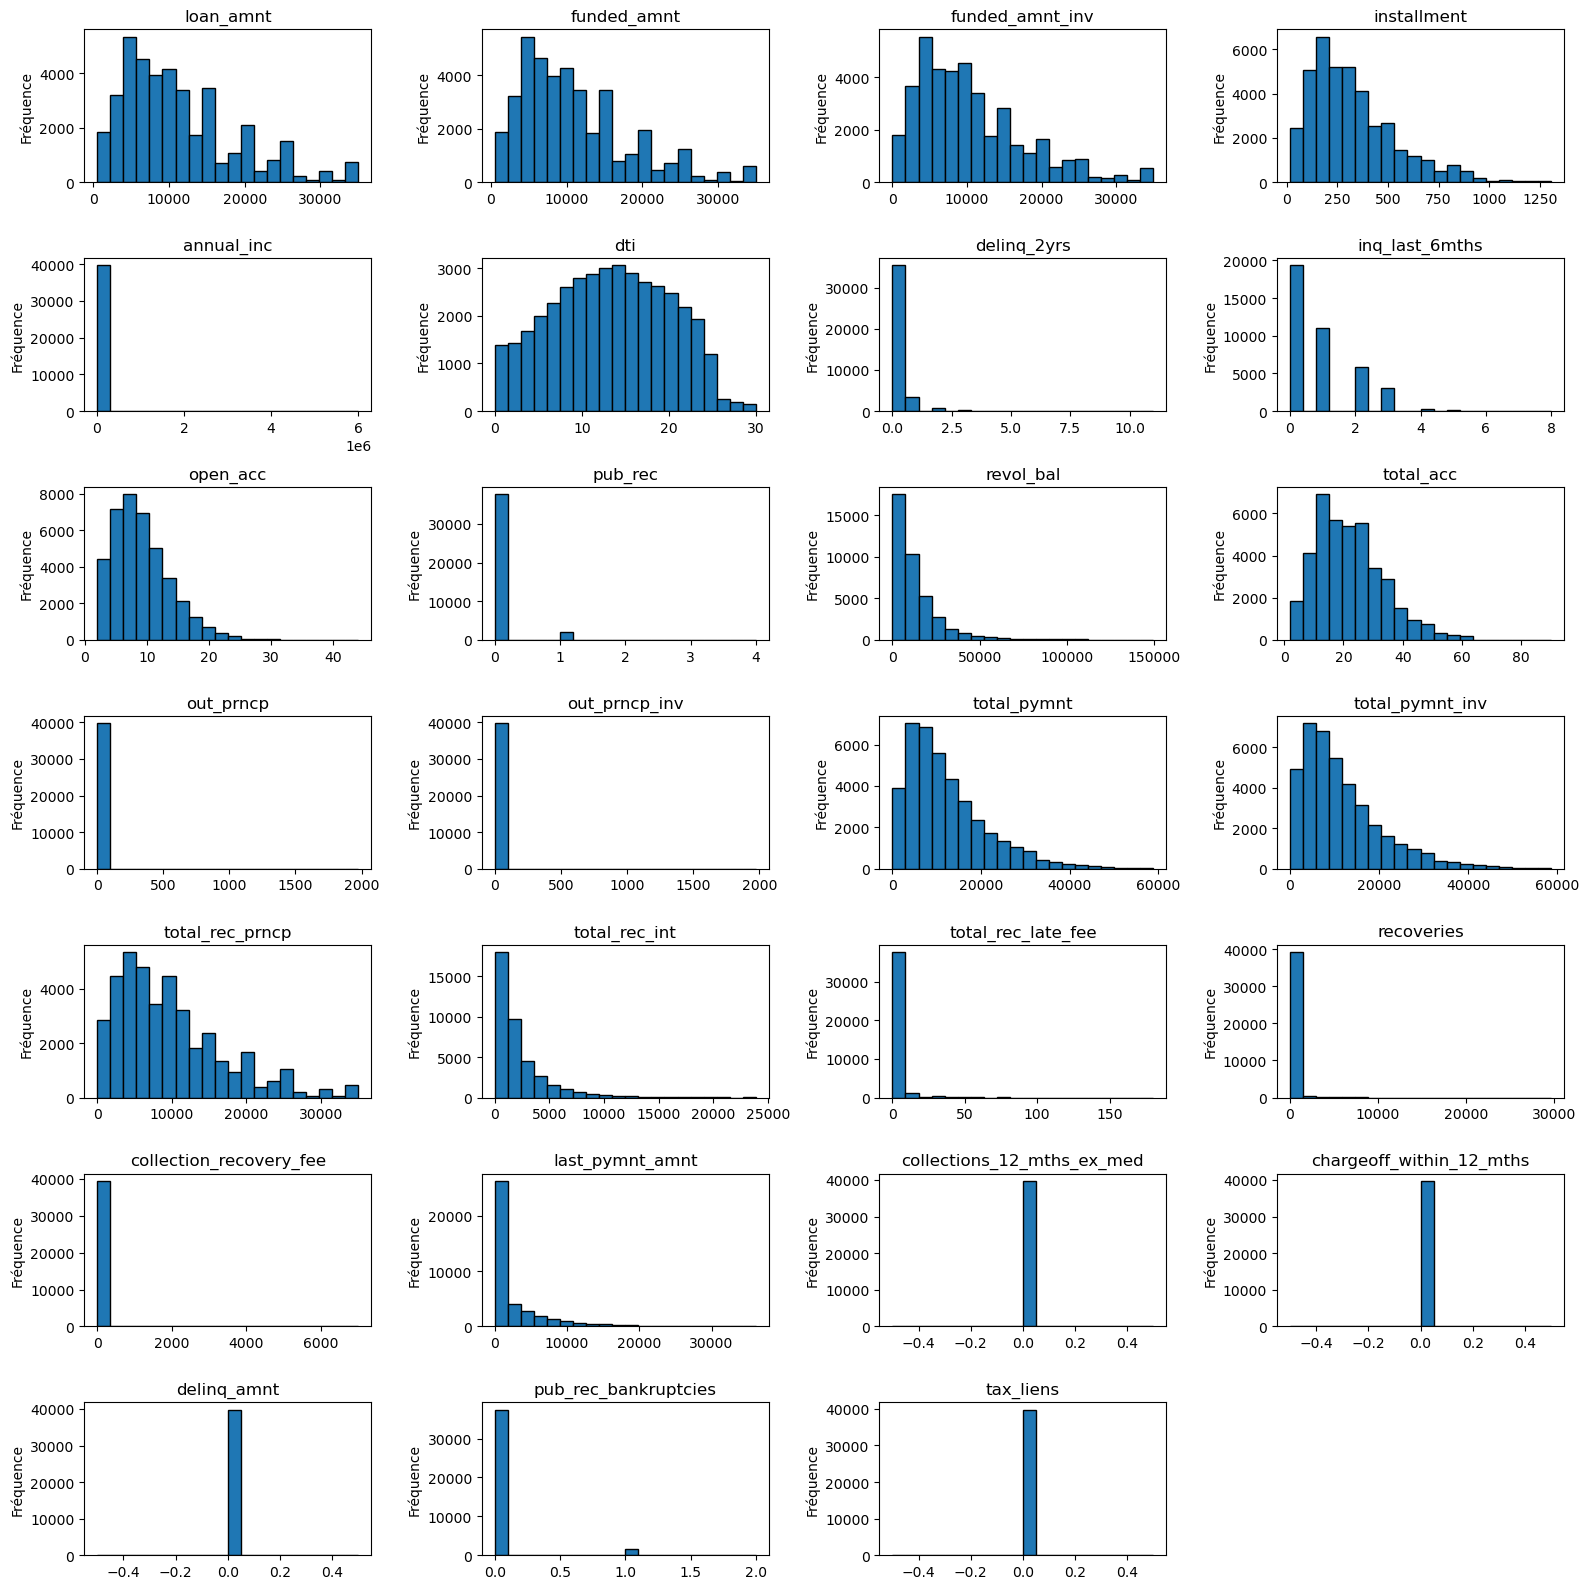

In [5]:
df_data_hist_plot = df_data.drop(columns=['id', 'member_id'], errors='ignore')
plot_distributions(df_data_hist_plot, bins=20)

## Identification de la variable cible
La variable cible est loan_status, ou derivable a partir de loan_status. 

## Sommaire de distribution 


Observations: 
* La table de sommaire de distribution plus bas permet de voir les types de nos variables. 
	- 29 variables sont numeriques; +2 colonnes "int_rate" et 'revol_util' qui sont reellements des pourcentages. 
	- 8 variables sont categorique; +1 si l'on inclue "zip_code" 
* 7 colonnes ont une cardinality de 1; indiquant une absence de variance dans ces colonnes et donc nous ne pouvons pas reelement tirer d'informations de ces colonnes. 
	- Corrections: Retirer ces 7 colonnes de notre dataset.  
* 2 colonnes *"int_rate" et 'revol_util'* sont identifie comme "string", mais sont en realite des valeurs numeriques. La presence d'un "%" cause ces colonnes a etre interprete comme des strings plutot que comme des numeriques (float). 
	- Correction: Convertir au format "float".  
* 4 colonnes *'last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line' et 'issue_d'* sont identifie comme "string", mais sont en realite des dates (MMM-yy). 
	- Corrections: Convertir au format "datetime". 

* *zip_code* est une variable string pouvant etre interpreter possiblement comme variable categorique, categorie geographique. Cependant la cardinality de cette variable etant tres eleve (800+), elle n'est peut-etre pas tres commode. Une analyse incluant des valeurs geographiques il serait peut-etre preferable d'utiliser "addr_state" qui possede une cardinality eleve, mais plus raisonnable. 

* Les skewness permettent de voir que nos variables ne sont pas normalement distribue (ce qui est previsible). Plusieurs variables sont tres eloigne d'une distribution normal: 
	- annual_inc skewness > 30  
	- out_prncp, out_prncp_inv skewness > 87  


In [6]:
summary = distributional_summary(df_data) 
varname_cardinality_1 = summary.loc[:, summary.loc['cardinality'] == 1].columns # ! to document. 
varname_date = ['last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line', 'issue_d']
varname_percentage = ['int_rate', 'revol_util']
varname_numerical = summary.loc[:, summary.loc['type'] == 'numerical'].columns # ! to document. 
varname_cat = ['emp_length', 'term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'loan_status', 'addr_state'] 

print(f'Colonnes avec cardinality de 1 \n{list(varname_cardinality_1)}\n') 

print(f'Colonnes date \n {varname_date}\n') 
print(f'Colonnes pourcentage \n {varname_date}\n') 
print(f'Nombre de colonnes numerique {len(varname_numerical)}') 
print(f'Nombre de colonnes categorique {len(varname_cat)}') 
summary

Colonnes avec cardinality de 1 
['pymnt_plan', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'chargeoff_within_12_mths', 'delinq_amnt', 'tax_liens']

Colonnes date 
 ['last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line', 'issue_d']

Colonnes pourcentage 
 ['last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line', 'issue_d']

Nombre de colonnes numerique 29
Nombre de colonnes categorique 8


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,application_type,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
type,numerical,numerical,numerical,numerical,numerical,string,string,numerical,string,string,...,numerical,string,numerical,string,numerical,string,numerical,numerical,numerical,numerical
dtype,int64,int64,int64,int64,float64,object,object,float64,object,object,...,float64,object,float64,object,float64,object,float64,int64,float64,float64
N,39786,39786,39786,39786,39786,39786,39786,39786,39786,39786,...,39786,39786,39786,39786,39786,39786,39786,39786,39786,39786
count,39786,39786,39786,39786,39786,39786,39786,39786,39786,39786,...,39786,39715,39786,39784,39730,39786,39730,39786,39089,39747
missing_p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.001785,0.0,0.00005,0.001408,0.0,0.001408,0.0,0.017519,0.00098
cardinality,39786,39786,885,1042,8215,2,371,15405,7,35,...,2663,109,35241,114,1,1,1,1,3,1
unique_p,1.0,1.0,0.004876,0.004424,0.179259,0.0,0.000427,0.228322,0.0,0.0,...,0.054768,0.000025,0.796034,0.000151,0.0,0.0,0.0,0.0,0.0,0.0
most_freq,87023,86999,10000,10000,5000.0,36 months,10.99%,311.11,B,B3,...,0.0,Mar-13,0.0,Jan-17,0.0,INDIVIDUAL,0.0,0,0.0,0.0
least_freq,87023,86999,6675,1125,9994.464812,60 months,16.71%,107.55,G,G5,...,77.175,Feb-08,3210.19,Jun-08,0.0,INDIVIDUAL,0.0,0,2.0,0.0
mean,683393.948726,850793.67569,11231.360277,10958.722289,10409.018679,NaN,NaN,324.733637,NaN,NaN,...,12.62539,NaN,2679.092793,NaN,0.0,NaN,0.0,0.0,0.043286,0.0


## Identification des valeures aberrantes(outliers)

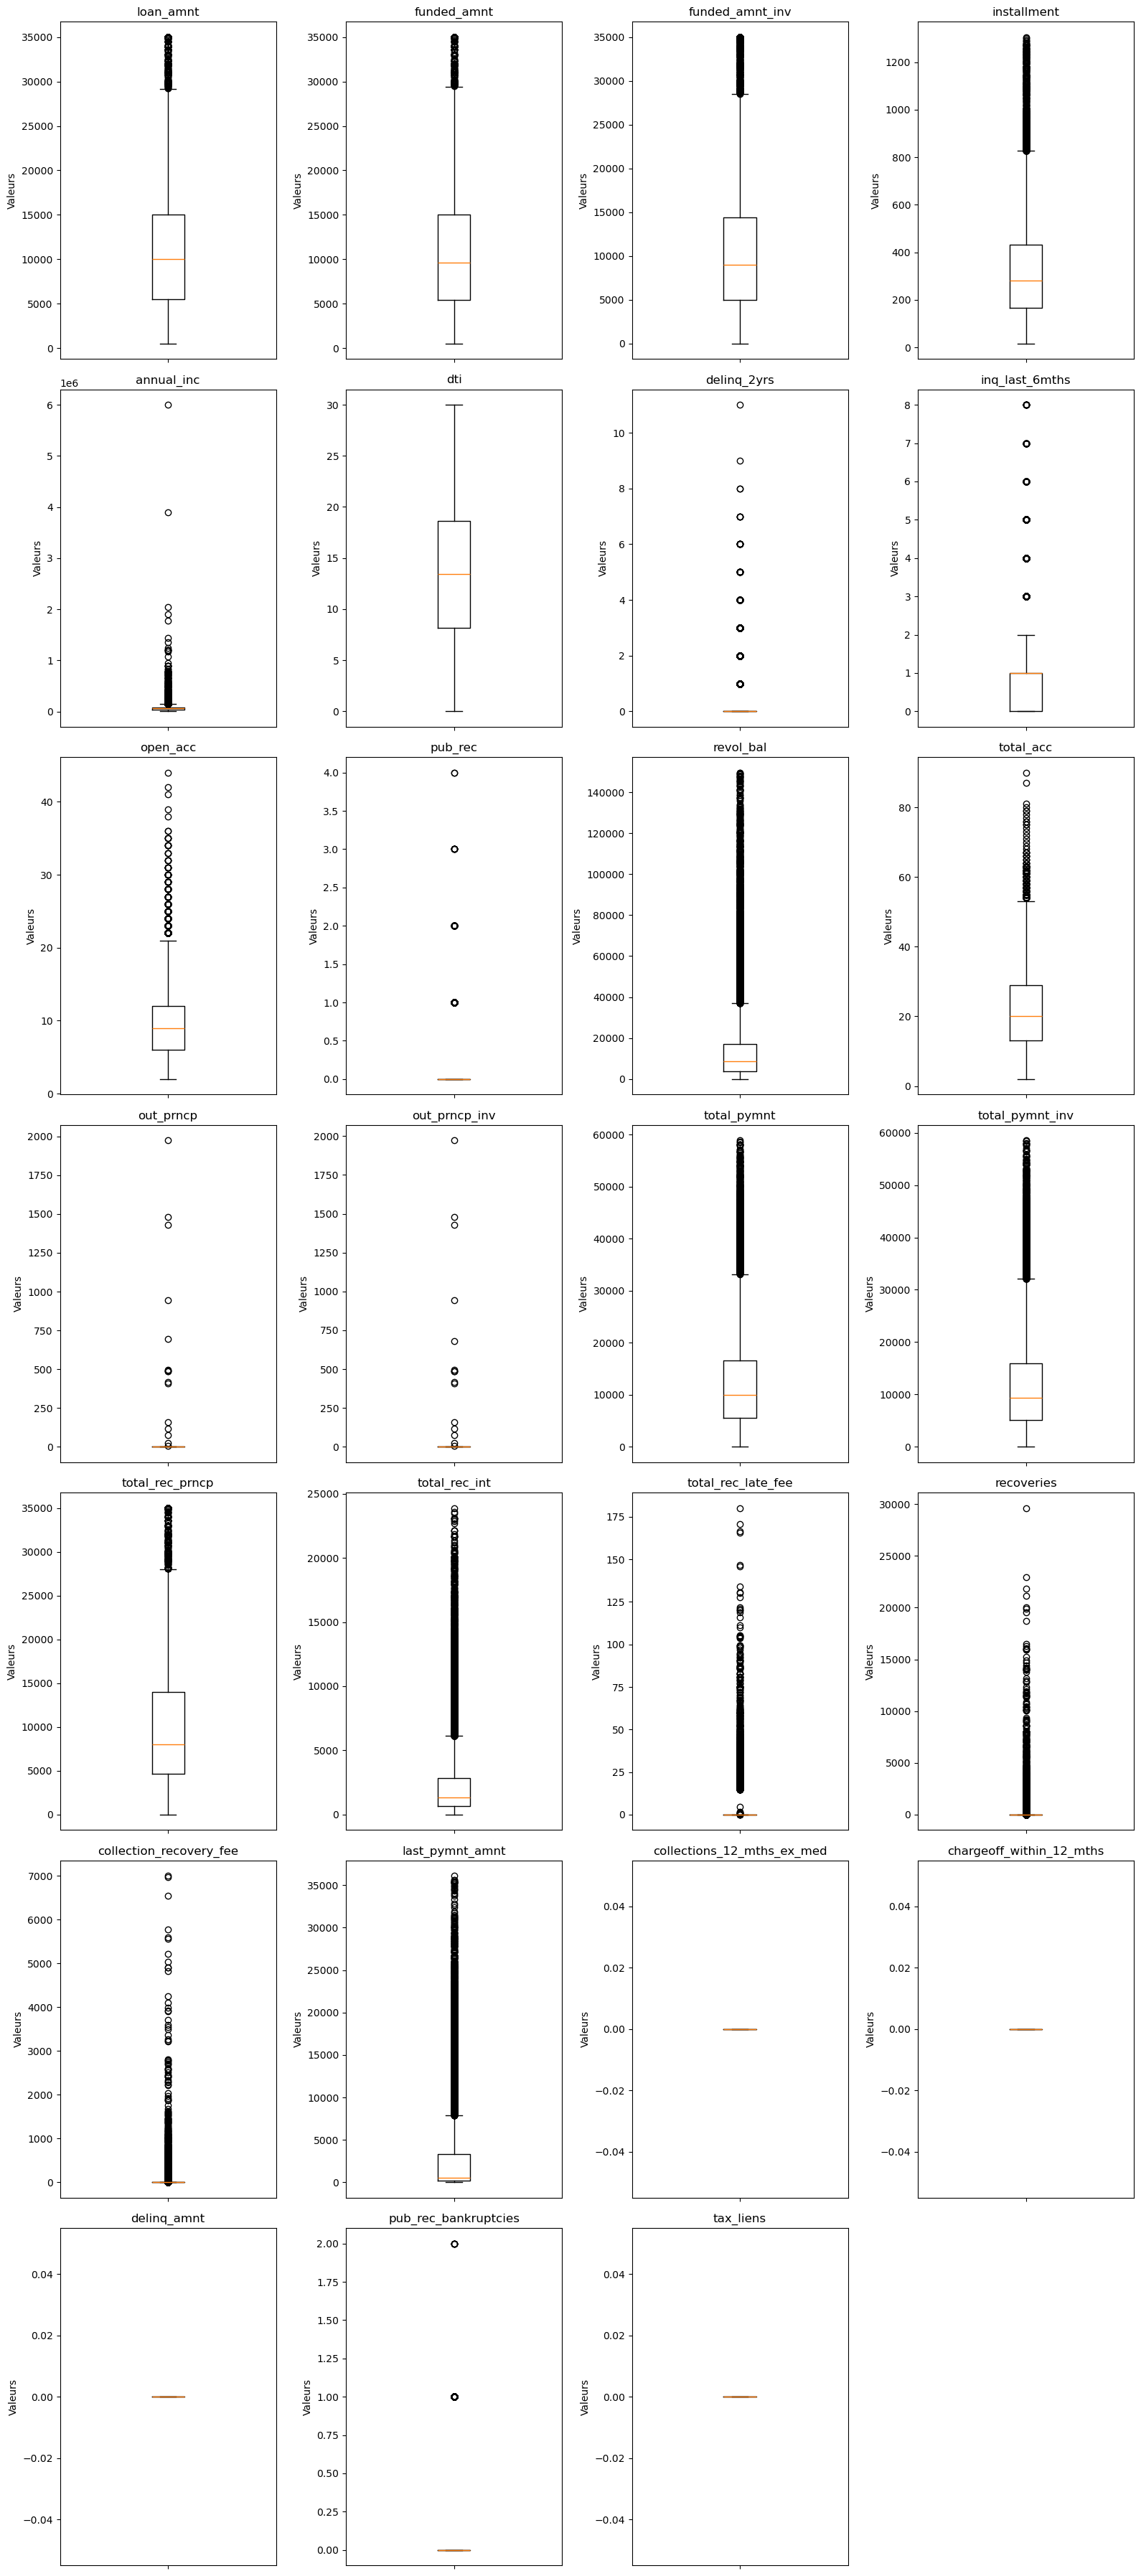

In [7]:
df_data_box_plot = df_data.drop(columns=['id', 'member_id'], errors='ignore')
plot_boxplots(df_data_box_plot, figsize=(16, 36))

## Identification de la variable cible

Observations:
Notre variable cible possede plus de 2 valeurs possibles. 
* Correction: il faudra regrouper les valeurs possibles de 'loan_status' en 2 categorie; 1:'Fully Paid', 0:'Not-fully paid' 

In [ ]:
df_data['loan_status'].value_counts() 

loan_status
Fully Paid            34108
Charged Off            5662
Late (31-120 days)       10
Current                   3
Late (16-30 days)         1
In Grace Period           1
Default                   1
Name: count, dtype: int64

## Completude

Observations: 
* 8 colonnes ont un pourcentage non null de missings 'emp_length', 'revol_util', 'last_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'pub_rec_bankruptcies', 'tax_liens'. Ces pourcentages de missings sont assez faibles. 
	- Corrections: Certaines imputations sont possibles. Dans d'autres cas, les observations avec valeurs manquantes devront etre retire. (Detail des corrections imputations et nettoyage dans la seconde partie). 
	- Corrections: Apres une premiere imputations recalculer la completude et reevaluer. 

In [9]:
#summary = distributional_summary(df_data) 

varname_with_missings = summary.loc[:, summary.loc['missing_p'] > 0].columns
print(f'Colonnes avec missings \n{varname_with_missings}\n')

# ! degree de completude
v_completeness = degree_completeness(df_data) 
h_completeness = degree_completeness(df_data, axis=1) 
v_completeness[v_completeness['completeness'] != 1].sort_values(by='completeness') 



Colonnes avec missings 
Index(['emp_length', 'revol_util', 'last_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'chargeoff_within_12_mths',
       'pub_rec_bankruptcies', 'tax_liens'],
      dtype='object')



,completeness
emp_length,0.972905
pub_rec_bankruptcies,0.982481
last_pymnt_d,0.998215
collections_12_mths_ex_med,0.998592
chargeoff_within_12_mths,0.998592
revol_util,0.998743
tax_liens,0.999020
last_credit_pull_d,0.999950


## Identification de variables categorique

Observation:
* En selectionnant les variables de types strings, a l'exclusion des colonnes a cardinality de 1, les colonnes de pourcentage et les colonnes de dates; il nous reste 8 ou 9 colonnes. 
* Le zip_code pourrait etre utilise comme valeur categorique regionale, mais le nombre de categorie etant tres elever de 823, ce n'etre peut-etre pas typiquement ideal. Elle pourrait etre transforme pour ne preserver que les 2 premiers caracteres et ainsi creer des plaque geographiques plus large ou etre exclue entierement a la faveur de la colonnes "addr_state" qui possede une cardinality 50 (plus raisonnable). Le choix finalement dependrait des besoins specifique d'une analyse (domain knowledge). 
* Le categorique "grade" et "sub_grade" sont colineaire. 
	- Corrections: Lors de l'analyse seulement utiliser l'une ou l'autres "grade" xor "sub_grade". 

* Corrections generales: Toutes les categoriques doivent etre transformer en dummy en preparation a l'analyse. 

In [10]:

cat_var = ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'loan_status', 'addr_state'] 

encodings = {
  'emp_length':{
    0: '< 1 year',
    1: '1 year',
    2: '2 years',
    3: '3 years',
    4: '4 years',
    5: '5 years',
    6: '6 years',
    7: '7 years',
    8: '8 years',
    9: '9 years',
    10: '10+ years'}
}
for c in cat_var:
	encodings[c] = { i:v for i,v in enumerate(sorted(df_data[c].unique()))} 
varname_cat = list(encodings.keys())

# ! Affiche summary pour les colonnes strings, excluant cardinality 1, excluant var de pourcentage et var date
sub_summary = summary[varname_cat]
print(f"Colonnes categoriques: \n{list(sub_summary.columns)}\n")
sub_summary

Colonnes categoriques: 
['emp_length', 'term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'loan_status', 'addr_state']



,emp_length,term,grade,sub_grade,home_ownership,verification_status,loan_status,addr_state
type,string,string,string,string,string,string,string,string
dtype,object,object,object,object,object,object,object,object
N,39786,39786,39786,39786,39786,39786,39786,39786
count,38708,39786,39786,39786,39786,39786,39786,39786
missing_p,0.027095,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cardinality,11,2,7,35,5,3,7,50
unique_p,0.0,0.0,0.0,0.0,0.0,0.0,0.000075,0.0
most_freq,10+ years,36 months,B,B3,RENT,Not Verified,Fully Paid,CA
least_freq,9 years,60 months,G,G5,NONE,Source Verified,Late (16-30 days),ME
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables categorique 
Sous la forme d'un dataframe representant les valeurs categoriques possible pour chaque variables. 

In [11]:
pd.DataFrame(encodings)

,emp_length,term,grade,sub_grade,home_ownership,verification_status,loan_status,addr_state
0,< 1 year,36 months,A,A1,MORTGAGE,Not Verified,Charged Off,AK
1,1 year,60 months,B,A2,NONE,Source Verified,Current,AL
2,2 years,NaN,C,A3,OTHER,Verified,Default,AR
3,3 years,NaN,D,A4,OWN,NaN,Fully Paid,AZ
4,4 years,NaN,E,A5,RENT,NaN,In Grace Period,CA
5,5 years,NaN,F,B1,NaN,NaN,Late (16-30 days),CO
6,6 years,NaN,G,B2,NaN,NaN,Late (31-120 days),CT
7,7 years,NaN,NaN,B3,NaN,NaN,NaN,DC
8,8 years,NaN,NaN,B4,NaN,NaN,NaN,DE
9,9 years,NaN,NaN,B5,NaN,NaN,NaN,FL
